In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
nav = pd.read_csv("data/processed/clean_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav = nav.sort_values(by=["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


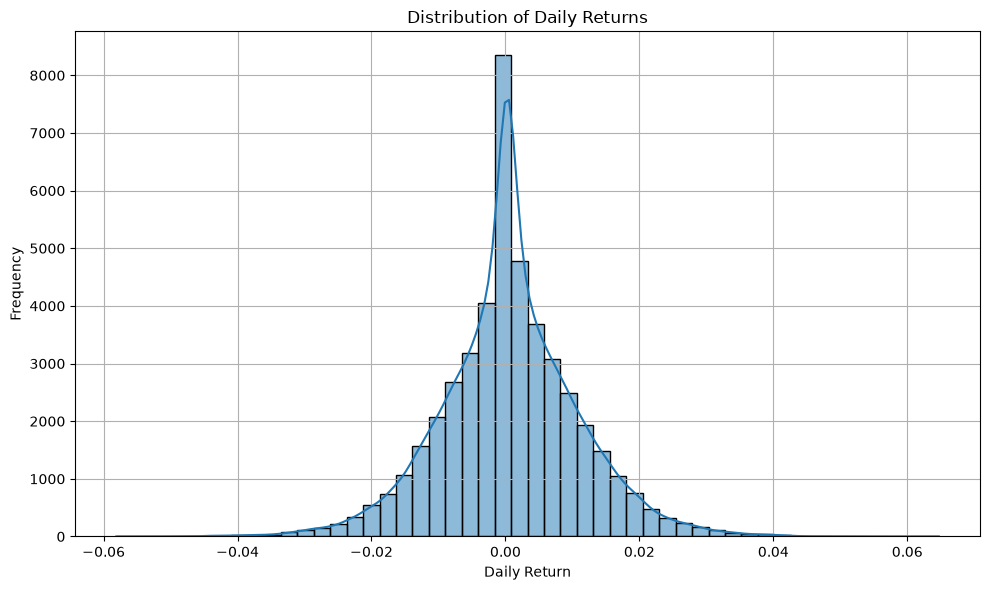

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/seaborn/daily_return_distribution.png",
    dpi=300
)

plt.show()

In [11]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [12]:
cagr_results = []

In [14]:
for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] - group.iloc[0]["date"]).days
    ) / 365

    cagr = calculate_cagr(start_nav, end_nav, years)

    cagr_results.append(
        {
            "amfi_code": code,
            "years": round(years, 2),
            "cagr": cagr
        }
    )

In [15]:
cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,years,cagr
0,100016,4.4,0.026352
1,100025,4.4,0.044551
2,100033,4.4,0.300997
3,101206,4.4,0.235205
4,101207,4.4,0.079331


In [16]:
cagr_df = cagr_df.sort_values(
    by="cagr",
    ascending=False
)

cagr_df.head(10)

,amfi_code,years,cagr
65,120505,4.4,0.328016
25,120505,4.4,0.328016
21,119598,4.4,0.323981
61,119598,4.4,0.323981
79,149324,4.4,0.322621
39,149324,4.4,0.322621
36,148569,4.4,0.319245
76,148569,4.4,0.319245
74,148567,4.4,0.309499
34,148567,4.4,0.309499


In [17]:
cagr_df.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [18]:
print(cagr_df.shape)

(80, 3)


In [19]:
print(cagr_df["amfi_code"].nunique())

40


In [20]:
cagr_results = []

In [21]:
for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] - group.iloc[0]["date"]).days
    ) / 365

    cagr = calculate_cagr(start_nav, end_nav, years)

    cagr_results.append({
        "amfi_code": code,
        "years": round(years, 2),
        "cagr": cagr
    })

In [22]:
cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.shape)
print(cagr_df["amfi_code"].nunique())

cagr_df.head()

(40, 3)
40


,amfi_code,years,cagr
0,100016,4.4,0.026352
1,100025,4.4,0.044551
2,100033,4.4,0.300997
3,101206,4.4,0.235205
4,101207,4.4,0.079331


In [23]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [24]:
sharpe_results = []

In [25]:
for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()
    std_return = returns.std()

    sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

In [26]:
sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [27]:
sharpe_df.to_csv(
    "reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [28]:
sortino_results = []

In [29]:
for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    avg_return = returns.mean()
    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

In [30]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [31]:
sortino_df.to_csv(
    "reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


In [32]:
print(benchmark.head())

NameError: name 'benchmark' is not defined

In [33]:
print(benchmark.columns.tolist())

NameError: name 'benchmark' is not defined

In [34]:
benchmark = pd.read_csv("data/raw/Bluestock_MF_Datasets/10_benchmark_indices.csv")

print(benchmark.head())
print(benchmark.columns.tolist())

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
['date', 'index_name', 'close_value']


In [35]:
print(benchmark.head())

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [36]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [37]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [38]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [39]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [40]:
alpha_beta_results = []

In [41]:
for code, group in nav.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

In [42]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [43]:
alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

Alpha & Beta saved successfully!


In [44]:
drawdown_results = []

In [45]:
for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Worst drawdown
    worst_idx = group["drawdown"].idxmin()

    drawdown_results.append({
        "amfi_code": code,
        "Maximum_Drawdown": group.loc[worst_idx, "drawdown"],
        "Worst_Date": group.loc[worst_idx, "date"]
    })

In [46]:
drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.sort_values(
    by="Maximum_Drawdown"
)

drawdown_df.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


In [47]:
drawdown_df.to_csv(
    "reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved successfully!")

Maximum Drawdown saved successfully!


In [48]:
performance = pd.read_csv(
    "data/processed/clean_scheme_performance.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [49]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [50]:
scorecard = performance[[
    "amfi_code",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,6.07,0.77,-0.226575,0.056209,-0.043287


In [51]:
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

In [52]:
scorecard["Fund_Score"] = (
      0.30 * scorecard["Return_Rank"]
    + 0.25 * scorecard["Sharpe_Rank"]
    + 0.20 * scorecard["Alpha_Rank"]
    + 0.15 * scorecard["Expense_Rank"]
    + 0.10 * scorecard["Drawdown_Rank"]
)

In [53]:
scorecard["Fund_Score"] = 100 * (
    scorecard["Fund_Score"].max() - scorecard["Fund_Score"]
) / (
    scorecard["Fund_Score"].max() - scorecard["Fund_Score"].min()
)

In [54]:
scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
12,120505,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,100.000000
22,120843,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,98.143852
7,100033,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,93.039443
2,119598,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,91.879350
34,148567,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,90.719258
39,149324,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,80.858469
38,149323,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,78.190255
11,120504,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,76.334107
26,119094,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,74.941995
36,148569,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,67.401392


In [55]:
scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


In [56]:
top5_funds = scorecard.head(5)["amfi_code"].tolist()

print(top5_funds)

[120505, 120843, 100033, 119598, 148567]


In [57]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

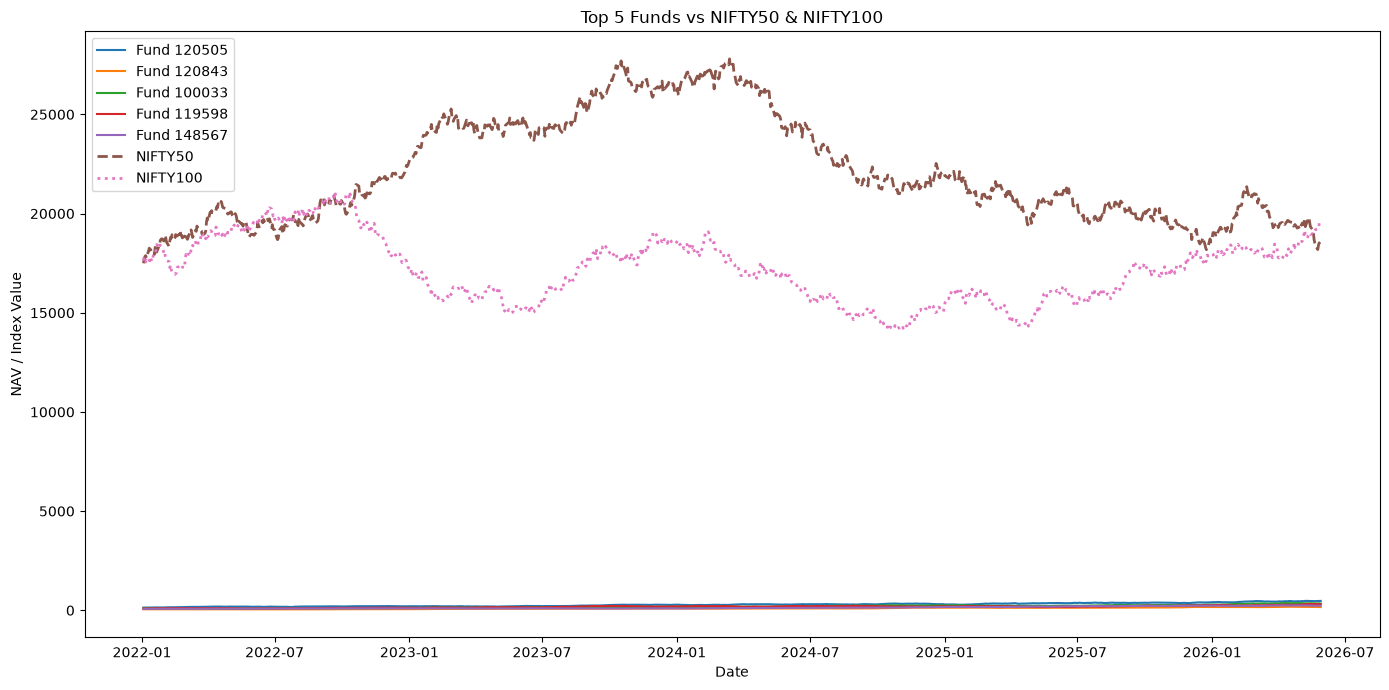

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for code in top5_funds:
    fund = nav[nav["amfi_code"] == code]
    plt.plot(
        fund["date"],
        fund["nav"],
        label=f"Fund {code}"
    )

# Plot Benchmarks
plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=2,
    linestyle="--",
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=2,
    linestyle=":",
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/matplotlib/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [64]:
tracking_error = []

for code in top5_funds:

    fund = nav[nav["amfi_code"] == code][
        ["date", "daily_return"]
    ].dropna()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df

,amfi_code,Tracking_Error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664


In [60]:
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value']


In [61]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [62]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [63]:
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [65]:
tracking_error_df.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!
